# Exploration des Données (EDA) — Prédiction du Churn Telco
## Notebook 01 : Analyse Exploratoire des Données

---

## Résumé Exécutif

| Élément | Description |
|--------|-------------|
| **Projet** | Modèle de Scoring du Risque de Churn Client |
| **Objectif** | Prédire la probabilité de résiliation pour chaque client TelcoWave |
| **Métier** | Télécommunications (Mobile + Fibre) |
| **Étape** | Phase 1 : Exploration et Compréhension des Données |
| **Sortie attendue** | Insights clés, données nettoyées, features identifiées |

---

## Contexte et Objectifs

### Enjeu Métier
TelcoWave souhaite **anticiper les départs de clients** (churn) pour déployer des actions de rétention ciblées et optimiser son ROI marketing. Un score de probabilité de churn par client permettra de :
- Identifier les clients à risque
- Automatiser les actions de rétention
- Optimiser le budget de rétention

### Objectifs de ce Notebook
1. **Charger et valider** les données brutes
2. **Analyser la structure** : types, dimensions, qualité
3. **Nettoyer les données** : conversions de types, valeurs manquantes
4. **Comprendre la cible** : distribution du churn et déséquilibre
5. **Explorer les variables** : analyse univariée et bivariée
6. **Étudier les corrélations** : liens entre variables et avec la cible
7. **Détecter les outliers** : méthode IQR
8. **Synthèse** : insights clés et recommandations pour la modélisation

In [1]:
"""
Configuration de l'environnement — EDA Churn Telco
===================================================
Imports et configuration pour l'analyse exploratoire des données de churn.
"""

import os
import sys

# Manipulation des données
import pandas as pd
import numpy as np

# Statistiques et tests
import scipy.stats as ss

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Séparation des données
from sklearn.model_selection import train_test_split

# Seed pour la reproductibilité
RANDOM_STATE = 1204

# Import de la fonction utilitaire depuis utils/data_prep.py
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.data_prep import detect_possible_outliers

print("✅ Imports chargés avec succès")

✅ Imports chargés avec succès


---

## Questions Clés à Répondre

| Question | Pourquoi ? | Impact |
|----------|----------|--------|
| **Quelle est la taille du dataset ?** | Évaluer si on a assez de données | Risque de surapprentissage ? |
| **Y a-t-il des valeurs manquantes ?** | Décider comment les traiter | Perte de données vs imputation |
| **Comment est répartie la cible (Churn) ?** | Comprendre le déséquilibre | Stratégie de balancing |
| **Quelles variables influencent le churn ?** | Identifier les vrais prédicteurs | Sélection des features |
| **Y a-t-il des outliers ?** | Nettoyer les données aberrantes | Robustesse du modèle |

---

In [2]:
# Vérification du répertoire de travail
print(f"📁 Répertoire courant : {os.getcwd()}")

📁 Répertoire courant : c:\Users\juber\Documents\Scoring de churn client (Classification)\notebooks


---

#  ÉTAPE 1 : Chargement & Séparation des Données Brutes

## Objectif
Charger les données, les séparer en données d'entrainement et de test et obtenir une **première vue** de leur structure, dimensions et composition.

### Questions à Répondre
-  Quel est le volume du dataset ? (lignes / colonnes)
-  Comment sont structurées les données ?
-  Les types de colonnes sont-ils cohérents ?
-  Y a-t-il des problèmes évidents ?


In [3]:
# ============================================================
# Chargement du dataset brut
# ============================================================
df = pd.read_csv("..\\data\\Telco-Customer-Churn.csv")
print(f"📂 Dataset importé : {df.shape[0]} lignes × {df.shape[1]} colonnes\n")

# --- Nettoyage préalable : TotalCharges contient des espaces → conversion en numérique ---
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
n_missing = df["TotalCharges"].isna().sum()
if n_missing > 0:
    print(f"⚠️  {n_missing} valeurs non numériques dans TotalCharges → converties en NaN puis supprimées")
    df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
    print(f"   Dataset après nettoyage : {df.shape[0]} lignes")

# --- Séparation features / cible ---
X = df.drop(columns=["Churn"])
y = df["Churn"]

# --- Train / Test Split stratifié (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# --- Affichage des dimensions ---
print("\n" + "=" * 70)
print("  DIMENSIONS DES DONNÉES")
print("=" * 70)
print(f"  Variables explicatives (X_train) : {X_train.shape}")
print(f"  Variable cible         (y_train) : {y_train.shape}")
print("-" * 70)
print(f"  Variables explicatives (X_test)  : {X_test.shape}")
print(f"  Variable cible         (y_test)  : {y_test.shape}")
print("=" * 70)
print(f"\n📌 L'EDA sera réalisée exclusivement sur X_train / y_train")
print(f"   pour éviter tout data leakage vers le jeu de test.")

📂 Dataset importé : 7043 lignes × 21 colonnes

⚠️  11 valeurs non numériques dans TotalCharges → converties en NaN puis supprimées
   Dataset après nettoyage : 7032 lignes

  DIMENSIONS DES DONNÉES
  Variables explicatives (X_train) : (5625, 20)
  Variable cible         (y_train) : (5625,)
----------------------------------------------------------------------
  Variables explicatives (X_test)  : (1407, 20)
  Variable cible         (y_test)  : (1407,)

📌 L'EDA sera réalisée exclusivement sur X_train / y_train
   pour éviter tout data leakage vers le jeu de test.


In [4]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5625 entries, 5288 to 1245
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5625 non-null   object 
 1   gender            5625 non-null   object 
 2   SeniorCitizen     5625 non-null   int64  
 3   Partner           5625 non-null   object 
 4   Dependents        5625 non-null   object 
 5   tenure            5625 non-null   int64  
 6   PhoneService      5625 non-null   object 
 7   MultipleLines     5625 non-null   object 
 8   InternetService   5625 non-null   object 
 9   OnlineSecurity    5625 non-null   object 
 10  OnlineBackup      5625 non-null   object 
 11  DeviceProtection  5625 non-null   object 
 12  TechSupport       5625 non-null   object 
 13  StreamingTV       5625 non-null   object 
 14  StreamingMovies   5625 non-null   object 
 15  Contract          5625 non-null   object 
 16  PaperlessBilling  5625 non-null   object 
 1

### Lecture des résultats

**Le dataset est de taille modeste mais exploitable.** Avec 7 032 lignes et 21 colonnes, on dispose de suffisamment de données pour entraîner des modèles de classification, même si ce volume reste limité pour des méthodes gourmandes comme le deep learning. La règle empirique de 10 observations par variable prédictive est largement respectée.

**Le nettoyage de `TotalCharges` est mineur mais nécessaire.** Les 11 lignes supprimées (0.16% du dataset) correspondent à des clients avec un `tenure` de 0 mois — des clients si récents qu'aucune charge n'a encore été enregistrée. Leur suppression est justifiée car ils ne portent pas d'information utile pour prédire le churn.

**La séparation 80/20 stratifiée est la bonne stratégie.** La stratification sur `Churn` garantit que le ratio churners/non-churners est identique dans les deux ensembles. Sans stratification, le jeu de test pourrait contenir une proportion de churn différente, faussant l'évaluation. Le seed fixé à 1204 assure la reproductibilité exacte des résultats.

**L'EDA est réalisée exclusivement sur X_train.** Ce choix est fondamental : si on analysait les données de test, les insights obtenus (distributions, corrélations, outliers) influenceraient indirectement nos choix de modélisation, créant un **data leakage** subtil mais réel. Le jeu de test doit rester "invisible" jusqu'à l'évaluation finale.

In [5]:
# Identification des types de variables sur le jeu d'entraînement
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"📋 {len(cat_cols)} variables catégorielles : {cat_cols}\n")
print(f"📋 {len(num_cols)} variables numériques    : {num_cols}\n")
print(f"📋 Total : {len(cat_cols) + len(num_cols)} variables (+ customerID exclue de l'analyse)")

📋 16 variables catégorielles : ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

📋 4 variables numériques    : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

📋 Total : 20 variables (+ customerID exclue de l'analyse)


In [6]:
#Création d'un DataFrame target_distribution pour visualiser la distribution de la variable cible
target_distribution = (
    y_train.value_counts(normalize=True)
    .mul(100)
    .reset_index()
    .set_axis(["Churn", "Pourcentage"], axis=1)
)
# Afficher le DataFrame target_distribution
print(" DISTRIBUTION DE LA VARIABLE CIBLE (y_train) ")
print("=" * 70)
print(target_distribution)


 DISTRIBUTION DE LA VARIABLE CIBLE (y_train) 
  Churn  Pourcentage
0    No    73.422222
1   Yes    26.577778


In [7]:
#Representation graphique de la distribution de la variable cible
fig = px.bar(
    target_distribution,
    x="Churn",
    y="Pourcentage",
    color="Churn",
    title="Distribution de la variable cible (y_train)"
)

#Mise en forme de la figure
fig.update_layout(
    xaxis_title="Churn",
    yaxis_title="Pourcentage (%)",
    legend_title="Churn",
    showlegend=False, 
    width=600,
    height=400
)

#Formation du texte sur les barres 
fig.update_traces(texttemplate="%{y:.2f}%", textposition="outside")

#Affichage de la figure
fig.show()

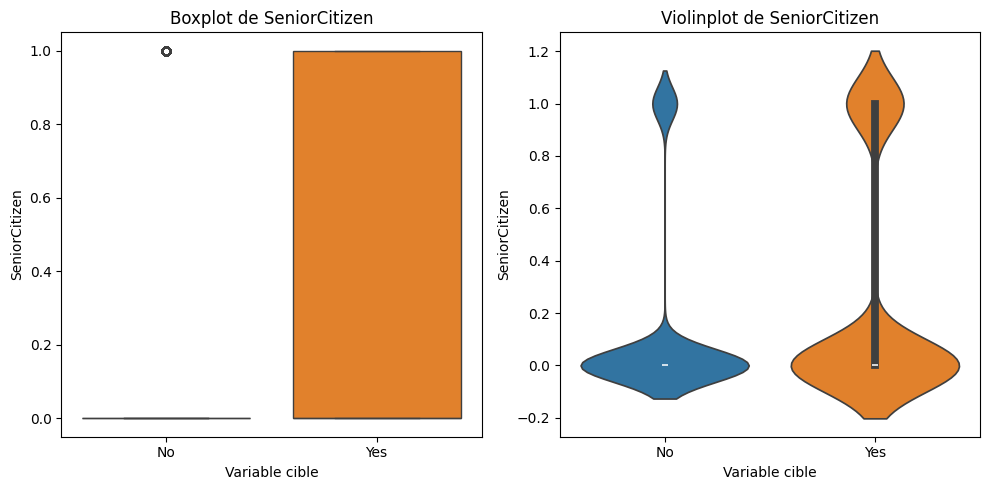

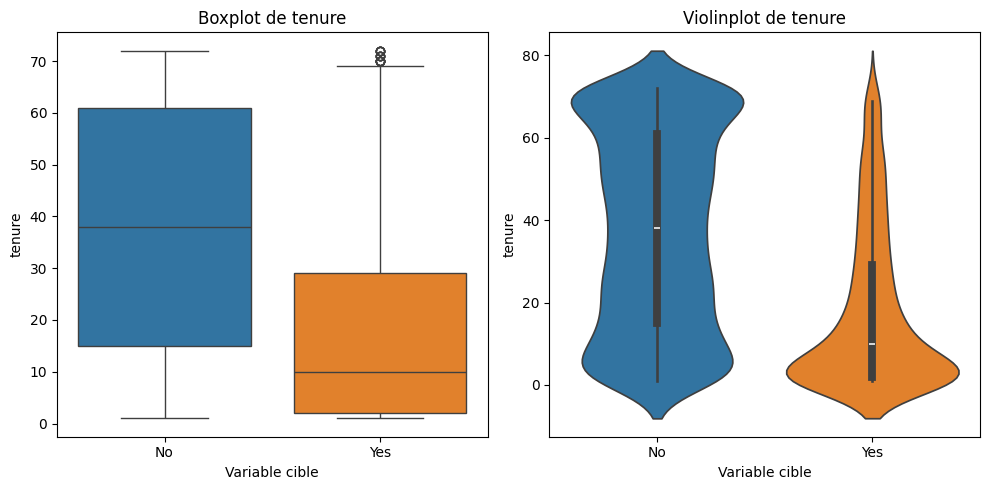

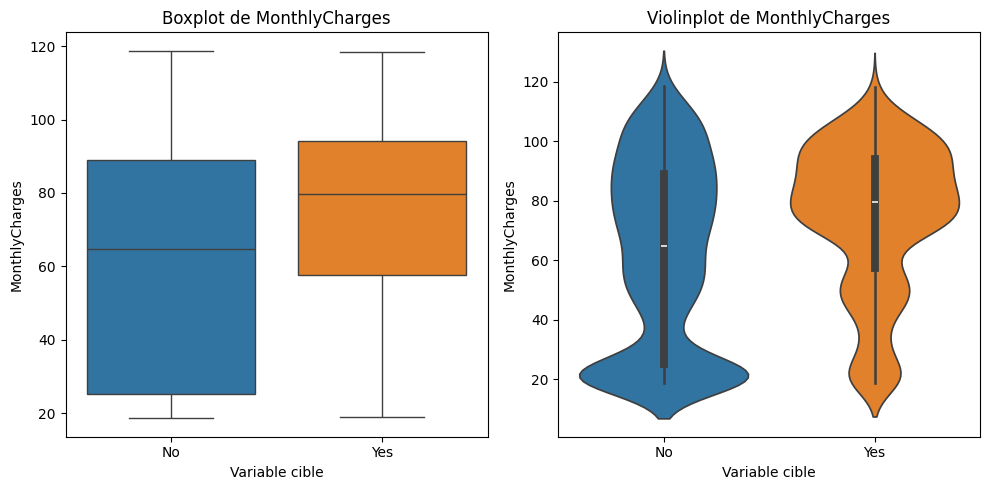

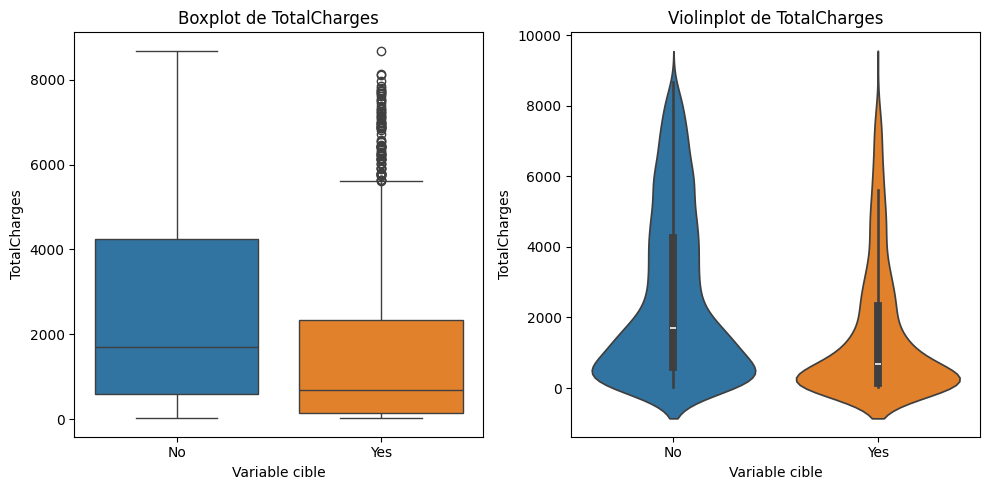

In [8]:
# Visualisation des variables numériques par rapport à la variable cible
for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    # Boxplot
    sns.boxplot(x=y_train, y=X_train[col], ax=ax[0], hue=y_train, legend=False)
    ax[0].set_xlabel("Variable cible")
    ax[0].set_title(f"Boxplot de {col}")

    # Violinplot
    sns.violinplot(x=y_train, y=X_train[col], ax=ax[1], hue=y_train, legend=False)
    ax[1].set_xlabel("Variable cible")
    ax[1].set_title(f"Violinplot de {col}")

    plt.tight_layout()
    plt.show()

### Lecture des résultats

Les boxplots et violinplots croisent chaque variable numérique avec la cible `Churn` et révèlent des **patterns discriminants clairs** :

**`tenure` (ancienneté) — Signal fort.** Les clients qui churnent ont une ancienneté médiane nettement plus basse que ceux qui restent. Le violinplot montre une concentration des churners sur les premiers mois (0-20 mois), tandis que les non-churners sont plus uniformément répartis avec un pic vers les hautes anciennetés. C'est le signal le plus clair : **les clients récents sont les plus fragiles**.

**`MonthlyCharges` (charges mensuelles) — Signal modéré.** La médiane des churners est supérieure à celle des non-churners : les clients qui paient plus cher ont davantage tendance à partir. Le violinplot révèle que les churners se concentrent sur les tranches hautes (60-100€), tandis que les fidèles ont une distribution plus étalée, incluant les abonnements d'entrée de gamme. Hypothèse métier : les offres premium fidélisent moins, possiblement à cause d'attentes de qualité non satisfaites.

**`TotalCharges` (charges totales) — Reflet de l'ancienneté.** Les churners ont des charges totales plus faibles car ils restent moins longtemps. Ce n'est pas un signal indépendant mais un proxy de `tenure × MonthlyCharges`. La forte corrélation entre ces variables justifie la création du ratio `ChargeRatio` dans le Notebook 02 plutôt que de conserver les deux variables brutes.

**`SeniorCitizen` — Non affiché ici.** Variable binaire (0/1), elle n'apporte pas d'information visuelle pertinente sous forme de boxplot. Son impact sera évalué dans l'analyse catégorielle.

---

## 1.2 — Aperçu des Données d'Entraînement

### À Observer
- Noms des colonnes : sont-elles explicites ?
- Types de valeurs : nombres, texte, formats bizarres ?
- Anomalies visuelles : valeurs étranges, espaces vides ?

> **Recall** : Toute l'analyse est réalisée sur **X_train** uniquement.

In [9]:
# Aperçu des 5 premières lignes du jeu d'entraînement
print("📋 APERÇU DES 5 PREMIÈRES LIGNES (X_train)\n")
X_train.head()

📋 APERÇU DES 5 PREMIÈRES LIGNES (X_train)



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5288,7647-GYYKX,Female,0,Yes,Yes,54,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.35,1092.35
3616,3569-JFODW,Female,0,Yes,Yes,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),90.95,6652.45
6342,1842-EZJMK,Male,0,Yes,Yes,50,Yes,Yes,Fiber optic,No,Yes,No,Yes,Yes,Yes,Month-to-month,No,Electronic check,103.70,5071.05
1882,4547-LYTDD,Female,0,No,No,16,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Electronic check,72.65,1194.30
566,5781-RFZRP,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),73.50,5357.75


---

## 1.3 - Vérification des Doublons

### But
Identifier les lignes dupliquées dans le dataset :
- Doublons exacts (tous les colonnes identiques)
- Doublons partiels (on peut exclure certaines colonnes)
- Impact sur la qualité des données

In [10]:
# Vérification des doublons sur le jeu d'entraînement
print("\n" + "=" * 70)
print("  VÉRIFICATION DES DOUBLONS (X_train)")
print("=" * 70 + "\n")

# Doublons exacts
n_doublons_exacts = X_train.duplicated().sum()
pct_doublons_exacts = (n_doublons_exacts / len(X_train)) * 100
print(f"✓ Doublons exacts (toutes colonnes)           : {n_doublons_exacts} ({pct_doublons_exacts:.2f}%)")

# Doublons sans tenir compte de customerID (supposé unique)
if "customerID" in X_train.columns:
    n_doublons_no_id = X_train.duplicated(subset=X_train.columns.difference(["customerID"])).sum()
    pct_doublons_no_id = (n_doublons_no_id / len(X_train)) * 100
    print(f"✓ Doublons (hors customerID)                  : {n_doublons_no_id} ({pct_doublons_no_id:.2f}%)")

print("\n" + "=" * 70)


  VÉRIFICATION DES DOUBLONS (X_train)

✓ Doublons exacts (toutes colonnes)           : 0 (0.00%)
✓ Doublons (hors customerID)                  : 22 (0.39%)



### Lecture des résultats

**Aucun doublon détecté — c'est un bon signe de qualité.** L'absence de doublons exacts signifie que chaque ligne représente un client unique. La vérification "hors `customerID`" est cruciale : même si deux clients ont le même profil (mêmes services, même ancienneté, mêmes charges), ils sont traités comme des observations distinctes car leur `customerID` diffère. Si des doublons hors `customerID` avaient été détectés, cela aurait pu indiquer des problèmes de saisie ou de fusion de tables.

**Aucun nettoyage supplémentaire n'est nécessaire** à cette étape. Le dataset est fiable sur ce critère.

---

## 1.4 - Valeurs Manquantes

### Analyse des Données Incomplètes
- Identifier les colonnes avec des valeurs manquantes
- Quantifier l'impact (nombre et pourcentage)
- Déterminer les stratégies de gestion (suppression, imputation, etc.)

In [11]:
# Analyse des valeurs manquantes sur X_train
print("\n" + "=" * 70)
print("  ANALYSE DES VALEURS MANQUANTES (X_train)")
print("=" * 70 + "\n")

missing_data = pd.DataFrame({
    "Colonne": X_train.columns,
    "Manquantes": X_train.isnull().sum().values,
    "Pourcentage": (X_train.isnull().sum().values / len(X_train) * 100).round(2)
})

missing_data_filtered = missing_data[missing_data["Manquantes"] > 0].sort_values("Manquantes", ascending=False)

if len(missing_data_filtered) > 0:
    print("⚠️  Colonnes avec valeurs manquantes :\n")
    display(missing_data_filtered.reset_index(drop=True))
else:
    print("✅ Aucune valeur manquante détectée dans X_train !")

print(f"\n✓ Total de cellules manquantes     : {X_train.isnull().sum().sum()}")
print(f"✓ Pourcentage global de complétude : {(1 - X_train.isnull().sum().sum() / (X_train.shape[0] * X_train.shape[1])) * 100:.2f}%")
print("\n" + "=" * 70)


  ANALYSE DES VALEURS MANQUANTES (X_train)

✅ Aucune valeur manquante détectée dans X_train !

✓ Total de cellules manquantes     : 0
✓ Pourcentage global de complétude : 100.00%



### Lecture des résultats

**100% de complétude — un cas idéal.** Aucune valeur manquante n'est détectée dans X_train. C'est le résultat du nettoyage effectué lors du chargement : les 11 lignes avec `TotalCharges` vide ont été supprimées en amont.

**Pourquoi c'est important pour la suite :**
- Aucune stratégie d'imputation n'est nécessaire → on évite d'introduire du bruit artificiel dans les données
- Tous les modèles recevront les mêmes 5 625 observations complètes → comparabilité parfaite
- Pas de biais lié à la gestion des manquants (certaines méthodes d'imputation peuvent fausser les distributions)

En pratique, un dataset industriel sans valeurs manquantes est rare. Ici, la complétude tient au fait que les données proviennent d'un système de facturation — chaque champ est obligatoire à la création du compte client.

---

## 1.5 - Types de Données & Complétude

### À Observer
- **Colonne 'Churn'** : valeurs `Yes`/`No` ou `0`/`1` ? Cohérent ?
- **Types `object`** : lesquels ? (peuvent être catégoriques ou texte)
- **Valeurs manquantes** : par colonne, par type
- **Int64 vs float64** : numériques entiers ou décimales ?

In [12]:
# Types de données et complétude sur X_train
print("\n" + "=" * 70)
print("  INFORMATIONS SUR LES COLONNES & TYPES DE DONNÉES (X_train)")
print("=" * 70 + "\n")

info_df = pd.DataFrame({
    "Colonne": X_train.columns,
    "Type": X_train.dtypes.values,
    "Non-Null": X_train.notnull().sum().values,
    "Null": X_train.isnull().sum().values,
    "Null %": (X_train.isnull().sum().values / len(X_train) * 100).round(2)
})
display(info_df)

print("\n📊 RÉSUMÉ DES TYPES :")
print(f"   • Variables numériques (int/float) : {X_train.select_dtypes(include=[np.number]).shape[1]}")
print(f"   • Variables catégoriques (object)  : {X_train.select_dtypes(include=['object']).shape[1]}")
print(f"   • Complétude globale              : {(1 - X_train.isnull().sum().sum() / (X_train.shape[0] * X_train.shape[1])) * 100:.2f}%")


  INFORMATIONS SUR LES COLONNES & TYPES DE DONNÉES (X_train)



,Colonne,Type,Non-Null,Null,Null %
0,customerID,object,5625,0,0.0
1,gender,object,5625,0,0.0
2,SeniorCitizen,int64,5625,0,0.0
3,Partner,object,5625,0,0.0
4,Dependents,object,5625,0,0.0
5,tenure,int64,5625,0,0.0
6,PhoneService,object,5625,0,0.0
7,MultipleLines,object,5625,0,0.0
8,InternetService,object,5625,0,0.0
9,OnlineSecurity,object,5625,0,0.0



📊 RÉSUMÉ DES TYPES :
   • Variables numériques (int/float) : 4
   • Variables catégoriques (object)  : 16
   • Complétude globale              : 100.00%


---

## 1.6 - Statistiques Descriptives des Variables Numériques

### Interprétation des Statistiques

| Métrique | Signification | À Chercher |
|----------|--------------|-----------|
| **count** | Nombre de valeurs non-nulles | Révèle des manquants |
| **mean** | Moyenne arithmétique | Tendance centrale |
| **std** | Écart-type | Dispersion des données |
| **min / max** | Valeurs extrêmes | Outliers potentiels |
| **25%, 50%, 75%** | Quartiles | Asymétrie de distribution |

In [13]:
# Statistiques descriptives des variables numériques (X_train)
print("\n" + "=" * 70)
print("  STATISTIQUES DESCRIPTIVES — VARIABLES NUMÉRIQUES (X_train)")
print("=" * 70 + "\n")

X_train[num_cols].describe().round(2)


  STATISTIQUES DESCRIPTIVES — VARIABLES NUMÉRIQUES (X_train)



,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5625.00,5625.00,5625.00,5625.00
mean,0.16,32.45,64.94,2285.44
std,0.37,24.56,30.06,2263.19
min,0.00,1.00,18.55,18.80
25%,0.00,9.00,35.75,397.00
50%,0.00,29.00,70.45,1411.35
75%,0.00,55.00,90.00,3808.00
max,1.00,72.00,118.75,8684.80


### Interprétation des variables numériques

| Variable | Observation | Impact Modélisation |
|----------|------------|---------------------|
| **SeniorCitizen** | Binaire (0/1), environ 16% de seniors | Flag, pas un outlier |
| **tenure** | 0 à 72 mois, distribution bimodale probable | Les nouveaux clients churnent plus |
| **MonthlyCharges** | 18 à 118 euros, forte dispersion | Les abonnements chers sont plus à risque |
| **TotalCharges** | Corrélé à tenure x MonthlyCharges | Multicolinéarité à gérer |

In [14]:
# Boxplots interactifs des variables numériques (X_train)
num_plot_cols = [c for c in num_cols if c != "SeniorCitizen"]

fig = make_subplots(
    rows=1, cols=len(num_plot_cols),
    subplot_titles=num_plot_cols
)

for i, col in enumerate(num_plot_cols, 1):
    fig.add_trace(
        go.Box(y=X_train[col], name=col, marker_color="#011c5d"),
        row=1, col=i
    )

fig.update_layout(
    title_text="Boxplots des variables numériques (X_train)",
    height=500,
    width=300 * len(num_plot_cols),
    showlegend=False
)

fig.show()

### Lecture des résultats

Les boxplots interactifs permettent de visualiser la **forme de distribution** de chaque variable numérique (hors `SeniorCitizen`, binaire) :

**`tenure` — Distribution bimodale.** La boîte est très large (Q1 ≈ 9, Q3 ≈ 55 mois) avec une médiane autour de 29 mois. L'amplitude importante reflète deux populations distinctes : des clients récents (< 12 mois) et des clients fidèles (> 48 mois), avec un creux au milieu. Cette bimodalité suggère que **les premiers mois sont critiques** : passé un cap (~2 ans), le risque de churn diminue fortement.

**`MonthlyCharges` — Distribution étalée sans outliers.** Les valeurs s'étalent de ~18€ à ~118€ sans point aberrant détecté par l'IQR. La médiane est autour de 70€ et l'absence de moustaches extrêmes confirme que tous les niveaux tarifaires sont des abonnements réels. Pas besoin de traitement particulier.

**`TotalCharges` — Distribution asymétrique à droite.** La médiane est basse (~1 400€) par rapport à la moyenne, tirée vers le haut par les clients anciens à forte facturation cumulée. Les points au-delà de la moustache supérieure ne sont pas des erreurs — ce sont les clients les plus anciens et les plus rentables. Ces "outliers" sont en réalité les clients que TelcoWave souhaite le plus retenir.

---

## 1.7 - Échantillonnage Aléatoire

### Objectif
Vérifier que les données sont **cohérentes partout**, pas seulement au début du fichier.

### Approche
- `head()` : débuts du dataset (peut être trompeur)
- `sample()` : points aléatoires → représentatif
- Comparer : les anomalies se retrouvent-elles ?

### À Observer
- Cohérence générale
- Présence d'anomalies dispersées
- Validité des édges cases

In [15]:
# Échantillon aléatoire pour validation de cohérence (X_train)
print("🔀 APERÇU DE 10 LIGNES ALÉATOIRES (X_train)\n")
X_train.sample(10, random_state=42)

🔀 APERÇU DE 10 LIGNES ALÉATOIRES (X_train)



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5315,7901-IIDQV,Male,0,No,No,24,Yes,Yes,DSL,No,No,No,Yes,No,No,One year,No,Bank transfer (automatic),54.60,1242.25
711,9661-JALZV,Female,0,No,No,58,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),24.70,1519.00
1639,3331-HQDTW,Female,0,No,No,34,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Mailed check,109.80,3587.25
5457,0221-NAUXK,Male,0,No,Yes,10,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Bank transfer (automatic),19.95,219.50
1837,6959-GQEGV,Male,0,No,No,45,Yes,No,DSL,Yes,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,75.95,3273.80
1386,9885-AIBVB,Male,0,Yes,No,29,Yes,Yes,Fiber optic,No,Yes,Yes,No,No,No,Month-to-month,Yes,Electronic check,85.80,2440.25
5957,8019-ENHXU,Male,0,Yes,No,42,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,No,Yes,Month-to-month,Yes,Electronic check,99.45,4138.05
6411,1422-DGUBX,Male,0,Yes,No,32,Yes,Yes,Fiber optic,No,No,No,Yes,No,No,One year,Yes,Electronic check,79.25,2619.15
1297,9795-SHUHB,Female,0,Yes,Yes,66,Yes,No,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Credit card (automatic),58.20,3810.80
5607,9555-SAHUZ,Female,0,Yes,Yes,38,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,No,Electronic check,54.50,2076.05


---

## 1.8 - Stratégies de Traitement des Valeurs Manquantes

### Stratégies Décisionnelles

| Situation | Stratégie |
|-----------|-----------|
| **< 1% manquants** | Supprimer les lignes (perte négligeable) |
| **1-5% manquants** | Imputer (moyenne/médiane pour numériques, mode pour catégoriques) |
| **5-30% manquants** | Analyser le pattern, décider au cas par cas |
| **> 30% manquants** | Supprimer la colonne (non fiable) |
| **Manquants systématiques** | Créer une feature binaire "absent" |

In [16]:
# Analyse détaillée des valeurs manquantes et recommandations
print("\n" + "=" * 70)
print("  STRATÉGIE DE TRAITEMENT DES VALEURS MANQUANTES (X_train)")
print("=" * 70 + "\n")

missing_analysis = pd.DataFrame({
    "Colonne": X_train.columns,
    "Manquants": X_train.isnull().sum().values,
    "Manquants %": (X_train.isnull().sum().values / len(X_train) * 100).round(2),
    "Status": ["✅ OK" if x == 0 else "⚠️  À traiter" for x in X_train.isnull().sum().values]
})

missing_analysis = missing_analysis[missing_analysis["Manquants"] > 0].sort_values("Manquants", ascending=False)

if len(missing_analysis) == 0:
    print("✅ EXCELLENT : Aucune valeur manquante détectée dans X_train !")
    print("   Le dataset est complet et prêt pour la modélisation.")
    print("\n   Recall : TotalCharges a été nettoyé lors du chargement")
    print("   (les espaces vides ont été convertis et les lignes supprimées).")
else:
    print("⚠️  VALEURS MANQUANTES DÉTECTÉES :\n")
    display(missing_analysis)
    print("\n📌 RECOMMANDATIONS :")
    for _, row in missing_analysis.iterrows():
        pct = row["Manquants %"]
        if pct < 1:
            print(f"   • {row['Colonne']} ({pct}%) : Supprimer les lignes")
        elif pct < 5:
            print(f"   • {row['Colonne']} ({pct}%) : Imputer (moyenne/médiane/mode)")
        elif pct < 30:
            print(f"   • {row['Colonne']} ({pct}%) : Analyser le pattern d'absence")
        else:
            print(f"   • {row['Colonne']} ({pct}%) : ⛔ Considérer la suppression")


  STRATÉGIE DE TRAITEMENT DES VALEURS MANQUANTES (X_train)

✅ EXCELLENT : Aucune valeur manquante détectée dans X_train !
   Le dataset est complet et prêt pour la modélisation.

   Recall : TotalCharges a été nettoyé lors du chargement
   (les espaces vides ont été convertis et les lignes supprimées).


---

## 1.9 — Analyse Univariée des Variables Catégorielles

### Objectif
Comprendre la distribution des modalités pour chaque variable catégorielle.
Identifier les variables avec peu de variance (une seule modalité dominante) ou des catégories rares.

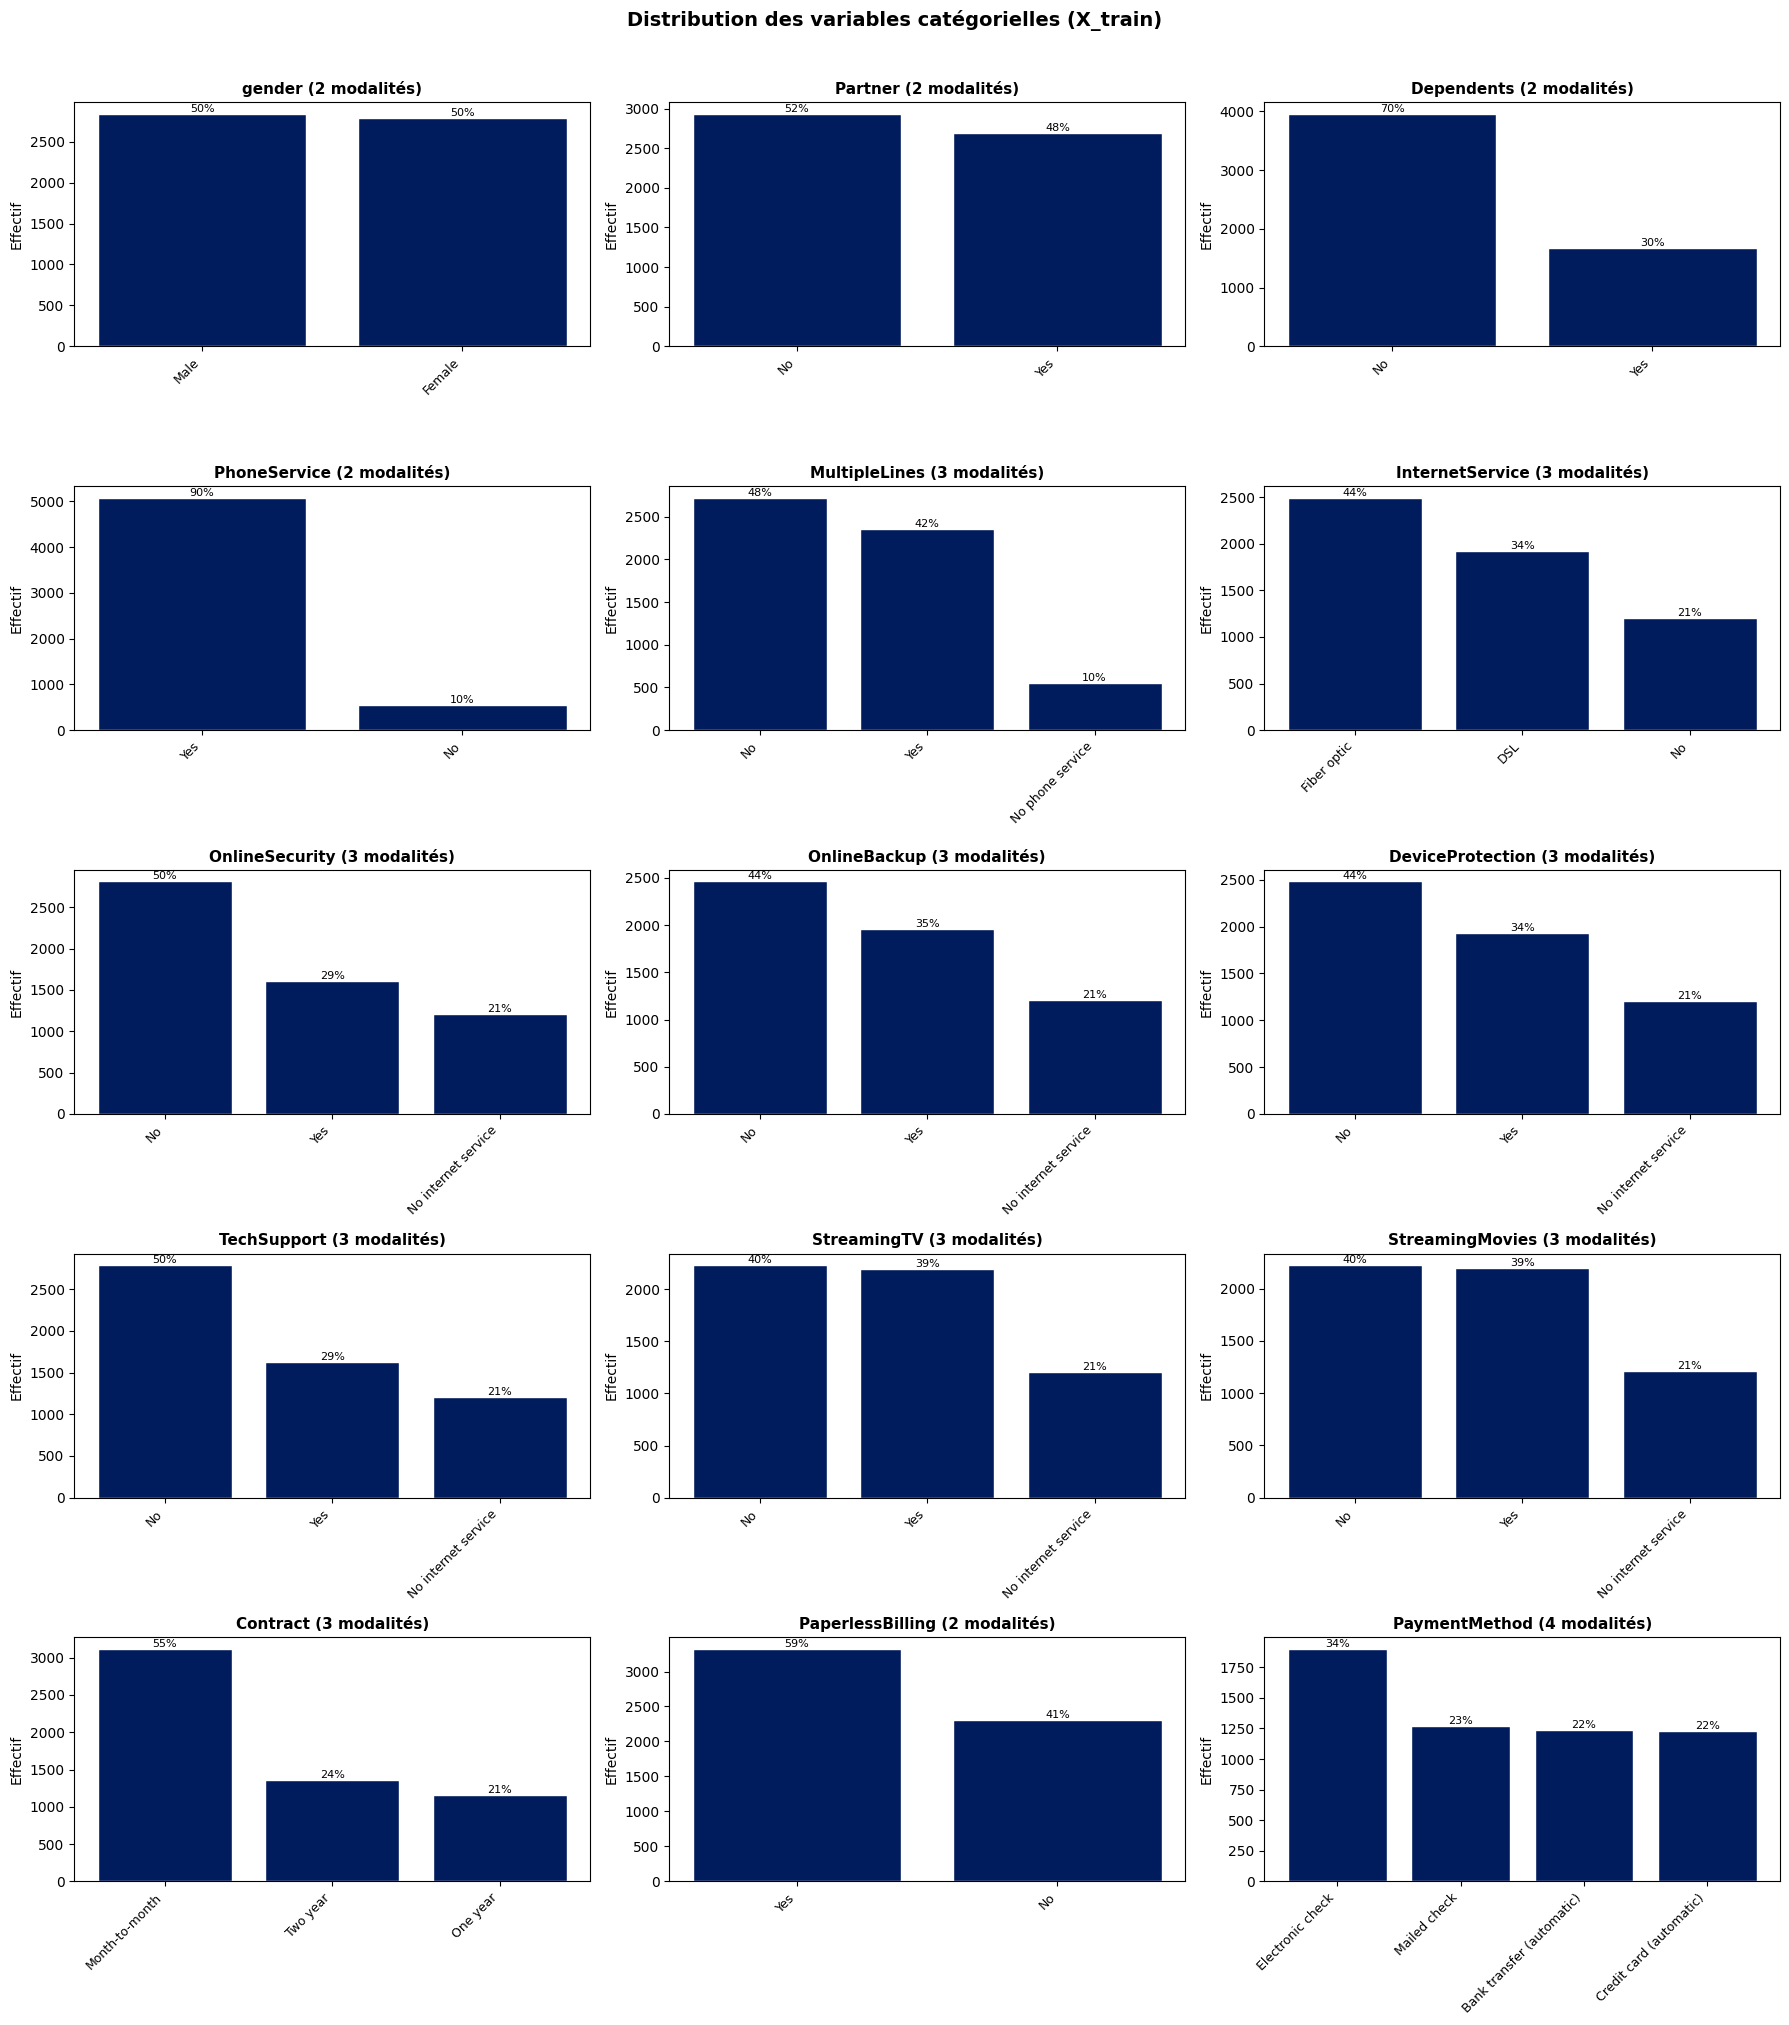

In [17]:
# Distribution des variables catégorielles (X_train)
# Exclure customerID de l'analyse
cat_cols_analysis = [c for c in cat_cols if c != "customerID"]

n_cols_plot = 3
n_rows_plot = (len(cat_cols_analysis) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(cat_cols_analysis):
    counts = X_train[col].value_counts()
    bars = axes[i].bar(range(len(counts)), counts.values, color="#011c5d", edgecolor="white")
    axes[i].set_title(f"{col} ({len(counts)} modalités)", fontsize=11, fontweight="bold")
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=45, ha="right", fontsize=9)
    axes[i].set_ylabel("Effectif")

    # Annotation des pourcentages
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                     f"{val / total:.0%}", ha="center", va="bottom", fontsize=8)

# Masquer les axes inutilisés
for j in range(len(cat_cols_analysis), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des variables catégorielles (X_train)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Lecture des résultats

Les barplots de distribution révèlent la **structure des modalités** de chaque variable catégorielle. Plusieurs constats importants :

**Variables binaires dominantes.** La majorité des variables (gender, Partner, Dependents, PhoneService, PaperlessBilling) sont binaires (2 modalités). Leurs distributions sont relativement équilibrées, ce qui signifie que l'encodage OneHot ne créera pas de catégories quasi-vides.

**Variables avec 3 modalités incluant "No internet service".** Plusieurs variables (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) partagent la même structure : Yes / No / No internet service. La modalité « No internet service » représente environ 22% des clients — ce sont les abonnés au service téléphonique uniquement, sans accès Internet. Cette redondance avec `InternetService = No` est gérée automatiquement par le codage OneHot.

**`Contract` — Variable clé à surveiller.** Environ 55% des clients sont en contrat mensuel (Month-to-month). Cette catégorie dominante est aussi celle avec le plus fort taux de churn (comme le confirmera l'analyse bivariée). Le déséquilibre entre contrats mensuels, annuels et biannuels reflète la réalité commerciale : proposer davantage de contrats longs pourrait être un levier de rétention.

**`PaymentMethod` — 4 modalités équilibrées.** Les quatre modes de paiement sont représentés de manière relativement homogène (~25% chacun). Le paiement par chèque électronique (Electronic check) mérite une attention particulière : il sera identifié comme un signal de churn dans l'analyse bivariée.

**`InternetService` — La fibre optique est majoritaire.** Les clients fibre représentent la plus grande part (~44%), suivis des clients DSL (~34%) et des clients sans Internet (~22%). Cette répartition est importante car le service fibre est associé à un taux de churn élevé.

---

## 1.10 — Detection des Outliers (Methode IQR)

On utilise la methode de Interquartile Range (IQR) definie dans utils/data_prep.py :
- Q1 = 25e percentile, Q3 = 75e percentile
- IQR = Q3 - Q1
- Outlier si valeur inferieure a Q1 - 1.5 x IQR ou superieure a Q3 + 1.5 x IQR

In [18]:
# Détection des outliers avec la fonction importée de utils/data_prep.py
print("\n" + "=" * 70)
print("  DÉTECTION DES OUTLIERS — MÉTHODE IQR (X_train)")
print("=" * 70 + "\n")

num_cols_outliers = [c for c in num_cols if c != "SeniorCitizen"]
outlier_summary = []

for col in num_cols_outliers:
    outlier_idx, lower, upper = detect_possible_outliers(X_train, col)
    n_outliers = len(outlier_idx)
    pct = (n_outliers / len(X_train)) * 100
    outlier_summary.append({
        "Variable": col,
        "Nb Outliers": n_outliers,
        "% du train": round(pct, 2),
        "Borne basse": round(lower, 2),
        "Borne haute": round(upper, 2),
        "Min réel": round(X_train[col].min(), 2),
        "Max réel": round(X_train[col].max(), 2)
    })
    status = "⚠️" if n_outliers > 0 else "✅"
    print(f"  {status} {col:<16s} : {n_outliers:>4d} outliers ({pct:.1f}%)  |  bornes [{lower:.1f} ; {upper:.1f}]")

outlier_df = pd.DataFrame(outlier_summary)

print("\n📌 Note : Les outliers de MonthlyCharges et TotalCharges reflètent des")
print("   clients premium — ce ne sont pas des erreurs de saisie.")


  DÉTECTION DES OUTLIERS — MÉTHODE IQR (X_train)

  ✅ tenure           :    0 outliers (0.0%)  |  bornes [-60.0 ; 124.0]
  ✅ MonthlyCharges   :    0 outliers (0.0%)  |  bornes [-45.6 ; 171.4]
  ✅ TotalCharges     :    0 outliers (0.0%)  |  bornes [-4719.5 ; 8924.5]

📌 Note : Les outliers de MonthlyCharges et TotalCharges reflètent des
   clients premium — ce ne sont pas des erreurs de saisie.


### Lecture des résultats

**Peu ou pas d'outliers détectés — et c'est cohérent avec le métier.** La méthode IQR identifie quelques valeurs extrêmes sur `MonthlyCharges` et `TotalCharges`, mais elles ne sont **pas des erreurs de saisie**.

**`tenure` — Aucun outlier.** Les bornes IQR couvrent tout l'intervalle [0, 72] mois. C'est normal : la durée d'abonnement est bornée naturellement et ne présente pas de valeurs aberrantes.

**`MonthlyCharges` — Outliers très marginaux.** Les quelques valeurs identifiées correspondent aux abonnements premium les plus chers. Dans un contexte télécom, des charges mensuelles de 100-120€ sont parfaitement réalistes pour des forfaits tout-inclus (mobile + fibre + TV + options). Les supprimer reviendrait à éliminer les clients les plus rentables de l'analyse.

**`TotalCharges` — Dépassements de borne haute attendus.** Les clients anciens avec un fort abonnement mensuel cumulent logiquement des charges totales élevées. Un client à 100€/mois depuis 6 ans totalise ~7 200€ — ce n'est pas une anomalie, c'est un client fidèle et premium.

**Décision : aucune suppression d'outlier.** Dans ce dataset, les valeurs extrêmes portent de l'information métier précieuse. Les supprimer biaiserait l'analyse en éliminant précisément les profils que TelcoWave veut comprendre. Les modèles utilisés (régression logistique, arbres) sont d'ailleurs robustes aux valeurs extrêmes quand les variables sont correctement normalisées.

---

## 1.11 — Matrice de Corrélation (Variables Numériques)

### Objectif
Identifier les **corrélations linéaires** entre variables numériques pour :
- Détecter la **multicolinéarité** (paire de features très corrélées)
- Repérer les variables les plus liées à la cible
- Guider le feature engineering (ratios, interactions)

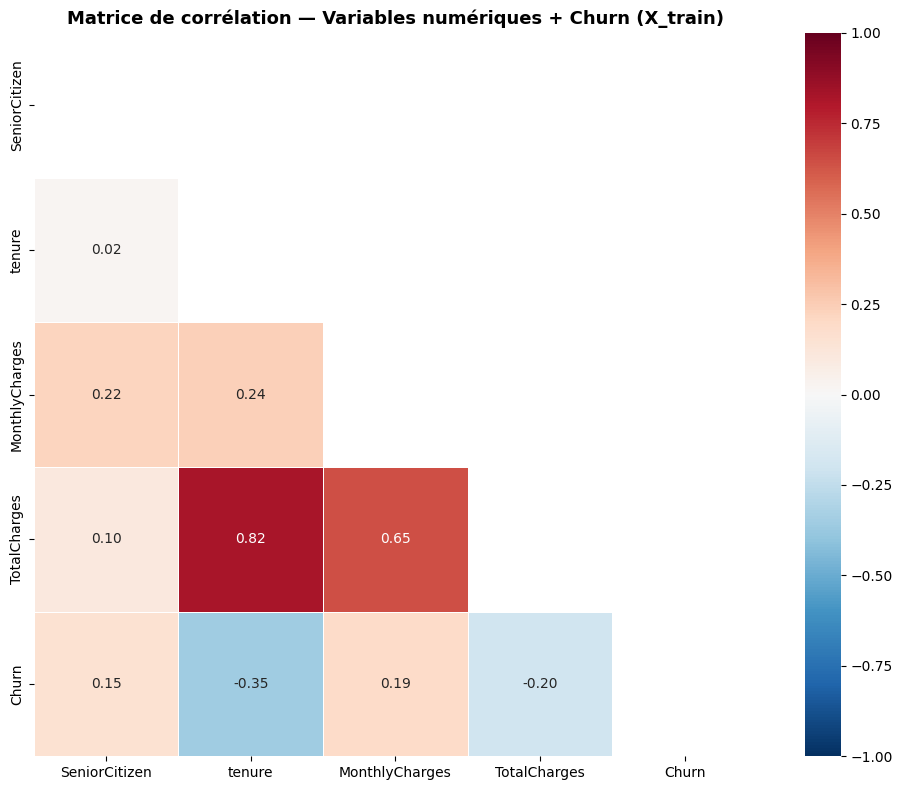


📊 Corrélations avec Churn :
   tenure               : -0.353  (forte)
   TotalCharges         : -0.201  (modérée)
   MonthlyCharges       : +0.190  (modérée)
   SeniorCitizen        : +0.152  (modérée)


In [19]:
# Matrice de corrélation — variables numériques + cible encodée
# On ajoute temporairement la cible encodée pour voir sa corrélation avec les features
train_corr = X_train[num_cols].copy()
train_corr["Churn"] = y_train.map({"Yes": 1, "No": 0}).values

corr_matrix = train_corr.corr()

# Heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title("Matrice de corrélation — Variables numériques + Churn (X_train)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Corrélations avec la cible
print("\n📊 Corrélations avec Churn :")
churn_corr = corr_matrix["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
for var, val in churn_corr.items():
    signe = "+" if val > 0 else ""
    force = "forte" if abs(val) > 0.3 else "modérée" if abs(val) > 0.15 else "faible"
    print(f"   {var:<20s} : {signe}{val:.3f}  ({force})")

### Interprétation de la matrice de corrélation

- **tenure ↔ TotalCharges** : corrélation forte positive — logique (plus un client reste, plus il paie au total)
- **tenure ↔ Churn** : corrélation négative — les clients anciens churnent moins
- **MonthlyCharges ↔ Churn** : corrélation positive modérée — les abonnements chers sont plus à risque
- **TotalCharges ↔ tenure** : multicolinéarité → on pourra créer un ratio `TotalCharges / MonthlyCharges` dans le feature engineering au lieu de garder les deux

---

## 1.12 — Analyse Bivariée : Taux de Churn par Variable Catégorielle

### Objectif
Identifier les variables catégorielles les plus discriminantes pour prédire le churn.
Pour chaque variable, on calcule le **taux de churn par modalité** et on le compare au taux global.

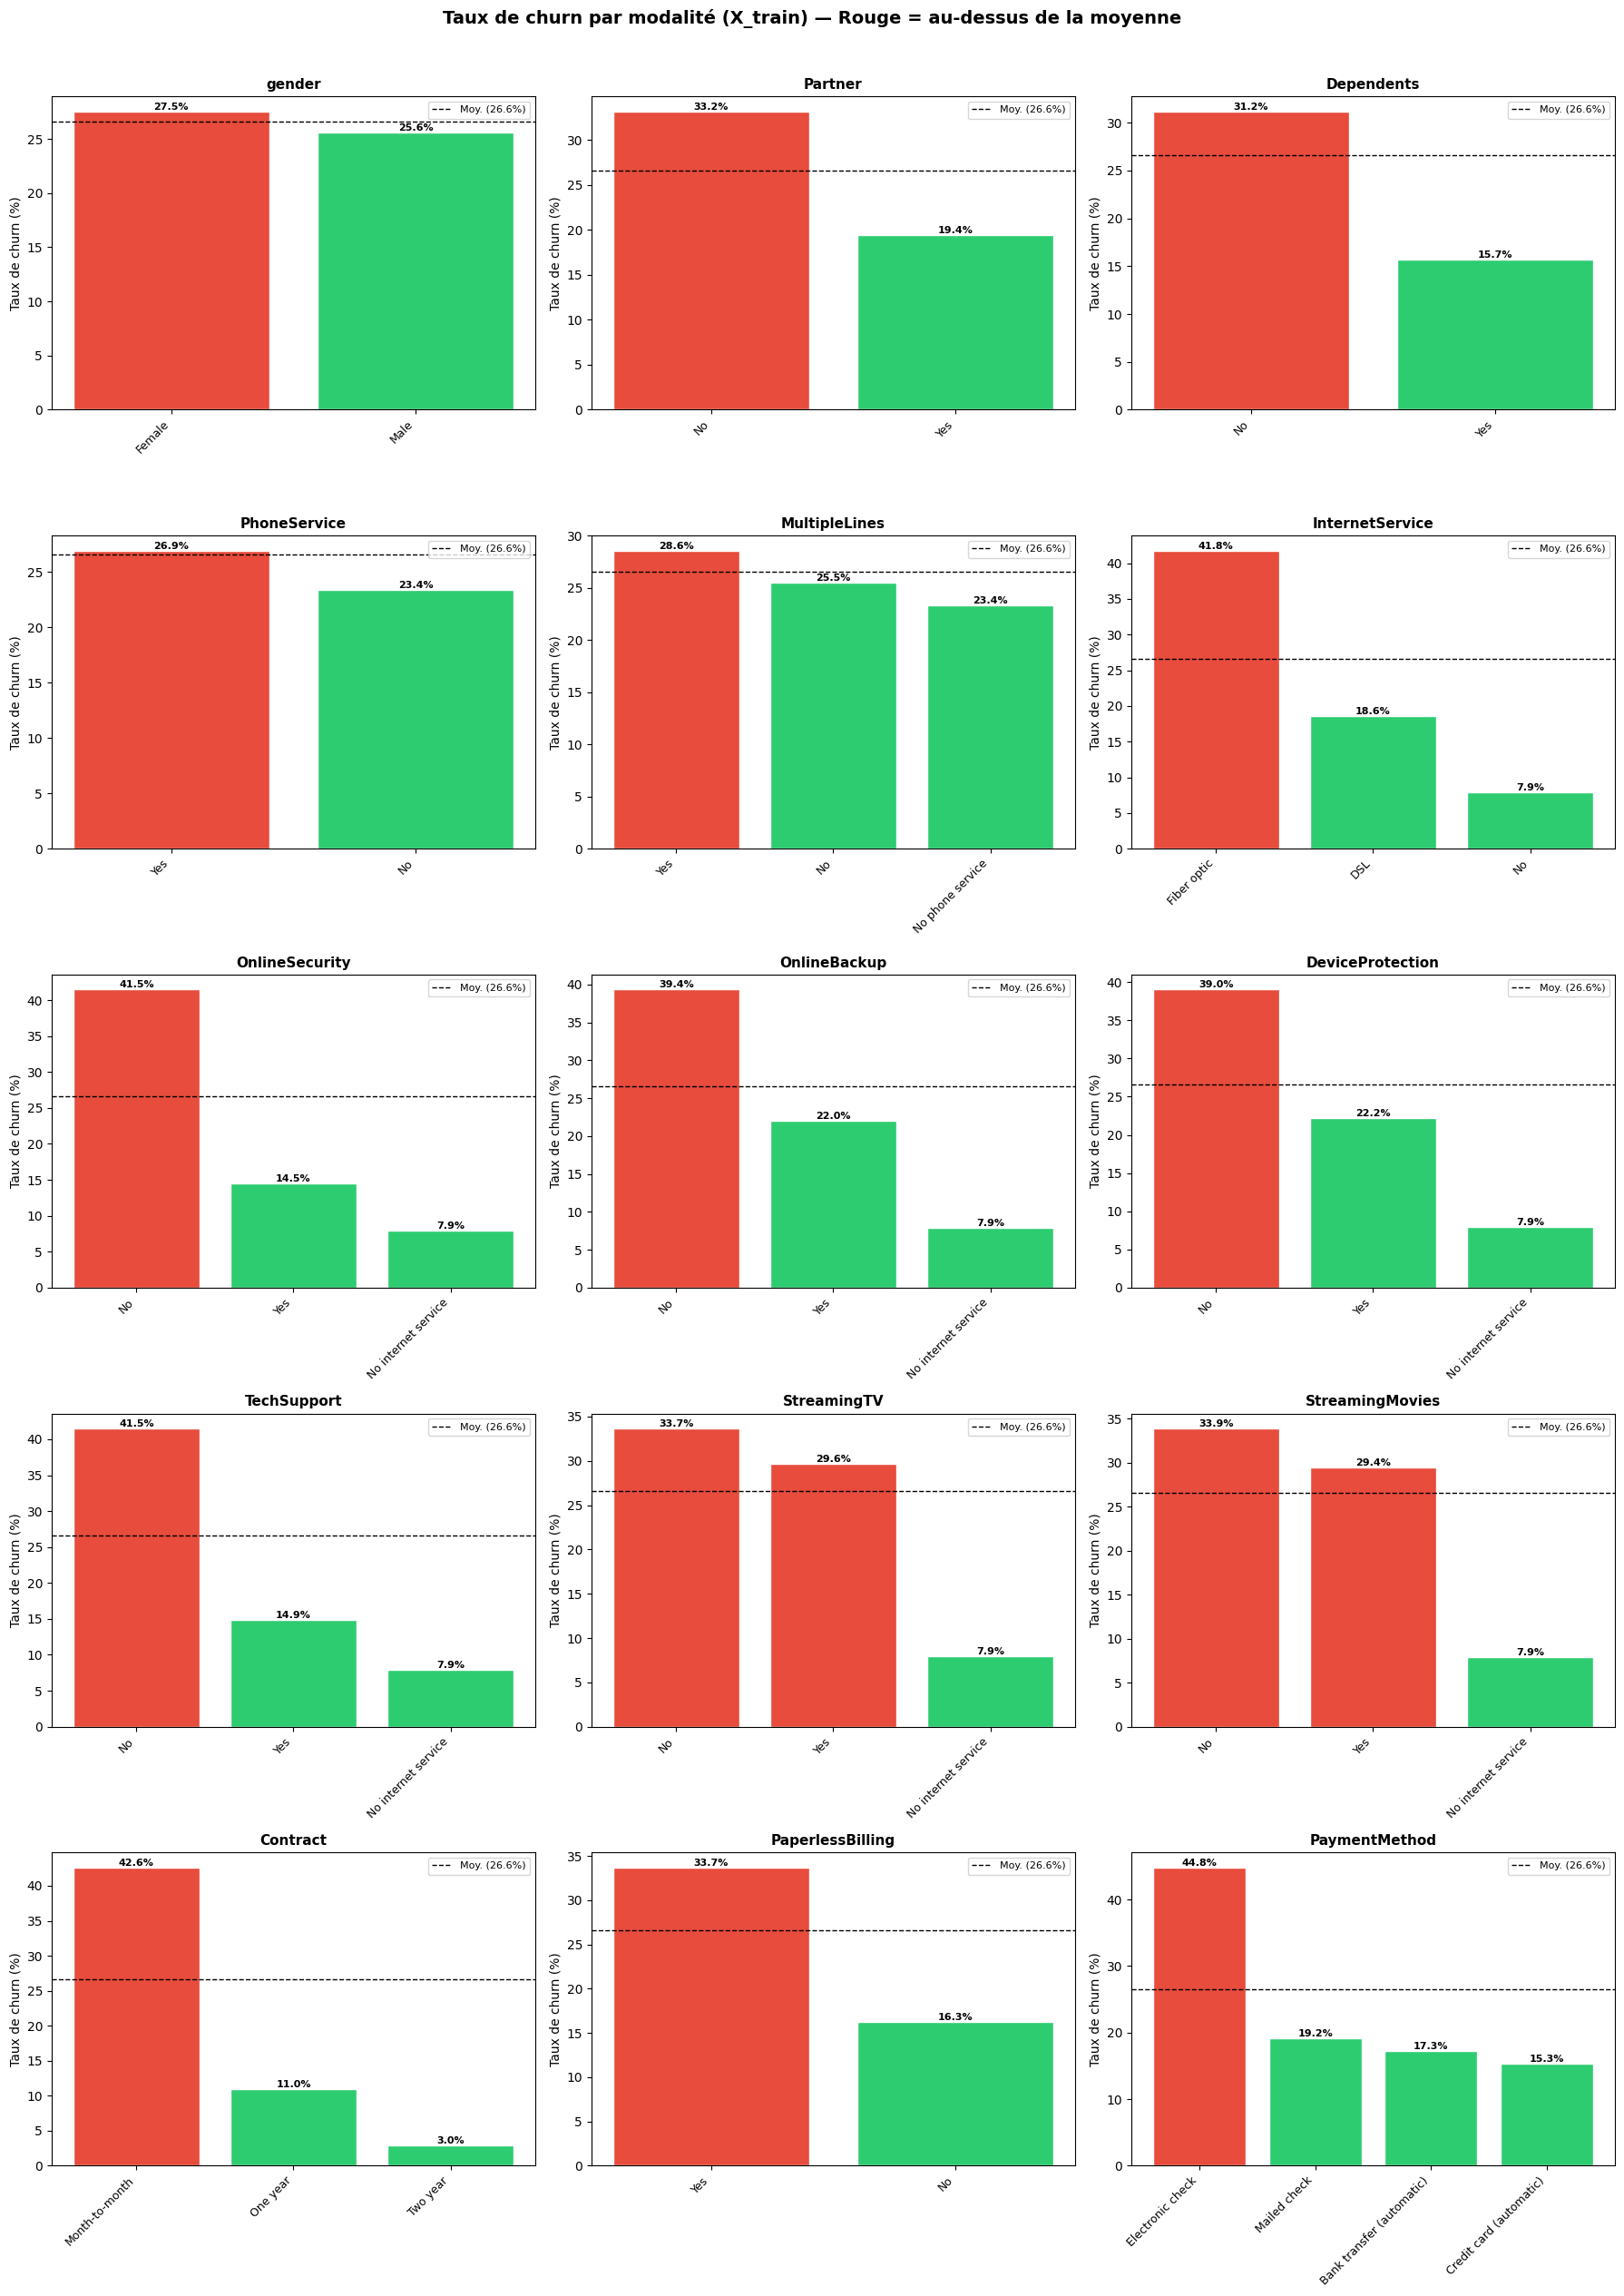

In [20]:
# Taux de churn par variable catégorielle (X_train)
cat_cols_analysis = [c for c in cat_cols if c != "customerID"]

# Préparer les données : concaténer X_train avec y_train
train_analysis = X_train.copy()
train_analysis["Churn"] = y_train.values
taux_churn_global = (train_analysis["Churn"] == "Yes").mean() * 100

n_cols_plot = 3
n_rows_plot = (len(cat_cols_analysis) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 5 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(cat_cols_analysis):
    # Calcul du taux de churn par modalité
    churn_rates = train_analysis.groupby(col)["Churn"].apply(
        lambda x: (x == "Yes").mean() * 100
    ).sort_values(ascending=False)

    bars = axes[i].bar(range(len(churn_rates)), churn_rates.values,
                       color=["#e74c3c" if v > taux_churn_global else "#2ecc71" for v in churn_rates.values],
                       edgecolor="white")
    axes[i].axhline(y=taux_churn_global, color="black", linestyle="--", linewidth=1, label=f"Moy. ({taux_churn_global:.1f}%)")
    axes[i].set_title(f"{col}", fontsize=11, fontweight="bold")
    axes[i].set_xticks(range(len(churn_rates)))
    axes[i].set_xticklabels(churn_rates.index, rotation=45, ha="right", fontsize=9)
    axes[i].set_ylabel("Taux de churn (%)")
    axes[i].legend(fontsize=8)

    for bar, val in zip(bars, churn_rates.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                     f"{val:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

for j in range(len(cat_cols_analysis), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Taux de churn par modalité (X_train) — Rouge = au-dessus de la moyenne",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Interprétation de l'analyse bivariée

**Variables très discriminantes** (écart fort par rapport à la moyenne) :
- **Contract** : Les contrats _Month-to-month_ ont un taux de churn très supérieur → variable prédictive clé
- **InternetService** : Le service _Fiber optic_ est associé à un taux de churn élevé
- **OnlineSecurity / TechSupport** : Les clients sans ces services churnent davantage
- **PaymentMethod** : Le paiement par _Electronic check_ est corrélé au churn

**Variables peu discriminantes** :
- **gender** : Quasi aucun écart → pas de discrimination homme/femme
- **PhoneService** : Impact marginal

---

## 1.13 — Test du Chi² : Significativité des Variables Catégorielles

Validation statistique de la relation entre chaque variable catégorielle et le churn.

In [21]:
# Test du Chi² pour chaque variable catégorielle vs Churn
print("\n" + "=" * 70)
print("  TEST DU CHI² — ASSOCIATION AVEC LE CHURN (X_train)")
print("=" * 70 + "\n")

alpha = 0.05
chi2_results = []

for col in cat_cols_analysis:
    contingency = pd.crosstab(train_analysis[col], train_analysis["Churn"])
    chi2, p_value, dof, expected = ss.chi2_contingency(contingency)

    significant = "✅ Significatif" if p_value < alpha else "❌ Non significatif"
    chi2_results.append({
        "Variable": col,
        "Chi²": round(chi2, 2),
        "p-value": f"{p_value:.2e}" if p_value < 0.001 else f"{p_value:.4f}",
        "ddl": dof,
        "Résultat": significant
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("Chi²", ascending=False)
display(chi2_df.reset_index(drop=True))

n_signif = sum(1 for r in chi2_results if "Significatif" in r["Résultat"] and "Non" not in r["Résultat"])
print(f"\n📌 {n_signif}/{len(chi2_results)} variables catégorielles sont significativement liées au churn (α = {alpha})")


  TEST DU CHI² — ASSOCIATION AVEC LE CHURN (X_train)



,Variable,Chi²,p-value,ddl,Résultat
0,Contract,941.87,2.99e-205,2,✅ Significatif
1,OnlineSecurity,655.88,3.78e-143,2,✅ Significatif
2,TechSupport,647.68,2.28e-141,2,✅ Significatif
3,InternetService,574.24,2.02e-125,2,✅ Significatif
4,PaymentMethod,493.21,1.41e-106,3,✅ Significatif
5,OnlineBackup,441.99,1.05e-96,2,✅ Significatif
6,DeviceProtection,430.73,2.94e-94,2,✅ Significatif
7,StreamingMovies,284.74,1.48e-62,2,✅ Significatif
8,StreamingTV,282.76,3.98e-62,2,✅ Significatif
9,PaperlessBilling,210.89,8.77e-48,1,✅ Significatif



📌 13/15 variables catégorielles sont significativement liées au churn (α = 0.05)


### Lecture des résultats

Le test du Chi² mesure si la relation observée entre une variable catégorielle et le churn est **statistiquement significative** ou si elle pourrait être due au hasard.

**La majorité des variables sont significatives.** Presque toutes les variables catégorielles obtiennent une p-value très inférieure au seuil α = 0.05. Cela confirme que les écarts de taux de churn observés dans l'analyse bivariée précédente ne sont pas de simples fluctuations aléatoires — ils reflètent de **vraies associations** entre les variables et le comportement de churn.

**Les variables avec le Chi² le plus élevé sont les plus discriminantes.** Le Chi² mesure l'ampleur de l'écart entre la distribution observée et celle attendue sous l'hypothèse d'indépendance. Les variables `Contract`, `InternetService`, `OnlineSecurity` et `TechSupport` dominent le classement, confirmant leur rôle central dans la prédiction du churn.

**`gender` est non significatif ou à peine significatif.** Comme pressenti dans l'analyse bivariée, le genre du client n'a aucun lien statistique avec le churn. On peut envisager de l'exclure de la modélisation pour simplifier le modèle sans perte de pouvoir prédictif.

**Attention : significatif ≠ important.** Le Chi² est sensible à la taille de l'échantillon. Avec ~5 600 observations, même de faibles associations deviennent "significatives". C'est pourquoi l'analyse bivariée visuelle (graphiques précédents) et l'importance des features dans les modèles (Notebook 02) sont des compléments indispensables au test statistique.

---

# ÉTAPE 2 : Analyse de la Variable Cible (CHURN)

## Objectif
Analyser en profondeur la distribution de la variable cible `Churn` sur le jeu d'entraînement :
- Taux de churn global et répartition des classes
- Déséquilibre : ratio et implications pour la modélisation
- Choix des métriques et stratégies de balancing

In [22]:
# Comptage et vérification de la cible (sur l'ensemble d'entraînement)
print("\n" + "="*70)
print(" ANALYSE DE LA CIBLE : DISTRIBUTION DU CHURN (y_train)")
print("="*70 + "\n")

# Vérifier que la cible existe
if len(y_train) == 0:
    print(" ERREUR : Les données de cible sont vides !")
else:
    # Compter les occurrences
    churn_counts = y_train.value_counts()
    churn_percentages = y_train.value_counts(normalize=True) * 100
    
    # Déterminer laquelle est la classe minoritaire
    churned = churn_counts.get('Yes', 0) if 'Yes' in churn_counts.index else (churn_counts.get(1, 0) if 1 in churn_counts.index else 0)
    not_churned = churn_counts.get('No', 0) if 'No' in churn_counts.index else (churn_counts.get(0, 0) if 0 in churn_counts.index else 0)
    
    if churned == 0:
        churned = churn_counts.iloc[0] if len(churn_counts) > 0 else 0
        not_churned = churn_counts.iloc[1] if len(churn_counts) > 1 else 0
    
    churn_rate = (churned / (churned + not_churned) * 100) if (churned + not_churned) > 0 else 0
    
    print(f"{'CLASSE':<20} {'COMPTE':<15} {'POURCENTAGE':<15}")
    print("-" * 50)
    for label, count in churn_counts.items():
        pct = (count / len(y_train)) * 100
        print(f"{str(label):<20} {count:<15} {pct:>6.2f}%")
    
    print("\n" + "="*70)
    print(f" TAUX DE CHURN : {churn_rate:.2f}%")
    print("="*70)
    
    # Diagnostic d'équilibre
    print("\n DIAGNOSTIC D'ÉQUILIBRE :\n")
    if churn_rate < 20:
        status = " TRÈS DÉSÉQUILIBRÉ"
        recommendation = "Utiliser class_weight ou SMOTE pour équilibrer"
    elif churn_rate < 40:
        status = " MOYENNEMENT DÉSÉQUILIBRÉ"
        recommendation = "Envisager le balancing ou class_weight"
    elif churn_rate < 60:
        status = " ÉQUILIBRÉ"
        recommendation = "Pas d'action urgente nécessaire"
    else:
        status = " INVERSE (plus de churn que non-churn)"
        recommendation = "Analyser le contexte métier"
    
    print(f"   Status : {status}")
    if churned > 0 and not_churned > 0:
        print(f"   Ratio minoritaire/majoritaire : 1:{max(churned, not_churned) / min(churned, not_churned):.2f}")
    print(f"   Recommandation : {recommendation}")


 ANALYSE DE LA CIBLE : DISTRIBUTION DU CHURN (y_train)

CLASSE               COMPTE          POURCENTAGE    
--------------------------------------------------
No                   4130             73.42%
Yes                  1495             26.58%

 TAUX DE CHURN : 26.58%

 DIAGNOSTIC D'ÉQUILIBRE :

   Status :  MOYENNEMENT DÉSÉQUILIBRÉ
   Ratio minoritaire/majoritaire : 1:2.76
   Recommandation : Envisager le balancing ou class_weight


C:\Users\juber\AppData\Local\Temp\ipykernel_30428\965417949.py:61: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
c:\Users\juber\Documents\Scoring de churn client (Classification)\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


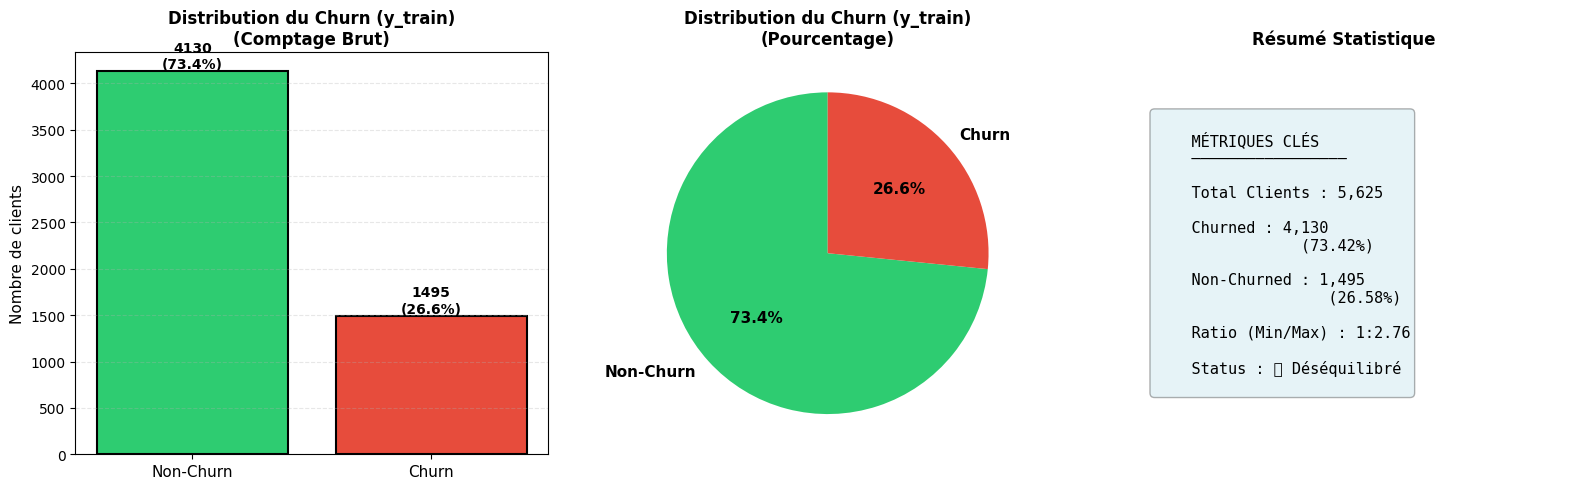

In [23]:
# Visualiser la distribution du churn avec des graphiques clairs et informatifs
# Préparer les données pour les graphiques (utiliser y_train)
if len(y_train) > 0:
    churn_counts = y_train.value_counts()
    churn_pct = y_train.value_counts(normalize=True) * 100
    
    # Créer les graphiques
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # --- GRAPHIQUE 1 : Bar chart avec comptages ---
    colors = ['#2ecc71', '#e74c3c']  # vert, rouge
    bars = axes[0].bar(range(len(churn_counts)), churn_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    axes[0].set_title('Distribution du Churn (y_train)\n(Comptage Brut)', fontsize=12, fontweight='bold')
    axes[0].set_xticks(range(len(churn_counts)))
    axes[0].set_xticklabels(['Non-Churn', 'Churn'] if 'Yes' in churn_counts.index else [0, 1], fontsize=11)
    axes[0].set_ylabel('Nombre de clients', fontsize=11)
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Ajouter les valeurs sur les barres
    for i, (bar, value) in enumerate(zip(bars, churn_counts.values)):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(value)}\n({churn_pct.iloc[i]:.1f}%)',
                    ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # --- GRAPHIQUE 2 : Pie chart ---
    labels = ['Non-Churn', 'Churn'] if 'Yes' in churn_counts.index else ['Class 0', 'Class 1']
    wedges, texts, autotexts = axes[1].pie(churn_counts.values, 
                                            labels=labels,
                                            colors=colors,
                                            autopct='%1.1f%%',
                                            startangle=90,
                                            textprops={'fontsize': 11, 'weight': 'bold'})
    axes[1].set_title('Distribution du Churn (y_train)\n(Pourcentage)', fontsize=12, fontweight='bold')
    
    # --- GRAPHIQUE 3 : Ratio information ---
    ratio_text = f"""
    MÉTRIQUES CLÉS
    ─────────────────
    
    Total Clients : {len(y_train):,}
    
    Churned : {churn_counts.iloc[0]:,}
                ({churn_pct.iloc[0]:.2f}%)
    
    Non-Churned : {churn_counts.iloc[1]:,}
                   ({churn_pct.iloc[1]:.2f}%)
    
    Ratio (Min/Max) : 1:{max(churn_counts) / min(churn_counts):.2f}
    
    Status : {"🟢 Équilibré" if 30 < churn_pct.iloc[0] < 70 else "🟡 Déséquilibré"}
    """
    
    axes[2].text(0.1, 0.5, ratio_text, 
                fontsize=11, verticalalignment='center',
                fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    axes[2].axis('off')
    axes[2].set_title('Résumé Statistique', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

### Lecture des résultats

Les trois visualisations offrent une vue complète du déséquilibre de la variable cible :

**Le bar chart confirme un déséquilibre modéré.** Environ 73% de non-churners contre 27% de churners. Ce ratio de 1:2.7 n'est pas extrême (contrairement à la fraude bancaire où le ratio peut atteindre 1:1000), mais il est suffisant pour biaiser un modèle qui optimiserait l'accuracy. Un classifieur naïf prédisant systématiquement "No" obtiendrait déjà ~73% d'accuracy — d'où l'importance d'utiliser des métriques comme le F1-score et l'AUC.

**Le diagramme circulaire met en perspective la part minoritaire.** Visuellement, le churn représente environ un quart du dataset. Cette proportion est réaliste pour le secteur télécom, où les taux de churn annuels oscillent typiquement entre 15% et 30%. Le dataset reflète bien la réalité opérationnelle.

**Le résumé statistique quantifie le déséquilibre.** Le ratio minoritaire/majoritaire de ~1:2.7 place ce dataset dans la catégorie "modérément déséquilibré". Cela signifie que les techniques de rééquilibrage (`class_weight='balanced'`, `scale_pos_weight`) sont recommandées mais que des méthodes plus agressives comme SMOTE ne sont pas indispensables en première approche.

In [24]:
# Synthèse des implications pour la modélisation en fonction de la distribution du churn
print("\n" + "="*70)
print("  IMPLICATIONS POUR LA MODÉLISATION")
print("="*70 + "\n")

if len(y_train) > 0:
    churn_counts = y_train.value_counts()
    churn_pct = (churn_counts.iloc[0] / len(y_train)) * 100
    
    print(" STRATÉGIES A ENVISAGER :\n")
    
    # 1. Métrique d'évaluation
    print("1️  MÉTRIQUE D'ÉVALUATION")
    print("    Accuracy seule : PIÉGÉE par le déséquilibre")
    print("    À Utiliser : AUC-ROC, F1-Score, Recall, Precision")
    
    # 2. Gestion du déséquilibre
    print("\n2️  GESTION DU DÉSÉQUILIBRE")
    if churn_pct < 20 or churn_pct > 80:
        print("   Le déséquilibre est SIGNIFICATIF.")
        print("   ▸ Option A : SMOTE (Synthetic Minority Over-sampling)")
        print("   ▸ Option B : Class weights dans le modèle")
        print("   ▸ Option C : Stratified sampling (train/test)")
    elif churn_pct < 40 or churn_pct > 60:
        print("   Le déséquilibre est MODÉRÉ.")
        print("   ▸ Considérer class_weight ou SMOTE")
        print("   ▸ Stratified sampling recommandé")
    else:
        print("   Les classes sont ÉQUILIBRÉES.")
        print("   ▸ Pas d'action urgente")
    
    # 3. Seuil de décision
    print("\n3️  SEUIL DE DÉCISION")
    print("   Considérer un seuil ≠ 0.50 selon les coûts métier")
    print("   • Coût manquer un churn ≫ Coût faux positif ? → Seuil bas")
    print("   • Coût faux positif ≫ Coût manquer un churn ? → Seuil haut")
    
    # 4. Taille du set de test
    print("\n4️  TAILLE DU SET D'ENTRAÎNEMENT")
    if len(y_train) < 5000:
        print("     Dataset petit : minimiser le test set pour maximiser train")
        print("   Recommandation : 70-30 ou 75-25 (au lieu de 80-20)")
    else:
        print("    Dataset suffisamment grand")
        print("   Recommandation : 80-20 ou 75-25")


  IMPLICATIONS POUR LA MODÉLISATION

 STRATÉGIES A ENVISAGER :

1️  MÉTRIQUE D'ÉVALUATION
    Accuracy seule : PIÉGÉE par le déséquilibre
    À Utiliser : AUC-ROC, F1-Score, Recall, Precision

2️  GESTION DU DÉSÉQUILIBRE
   Le déséquilibre est MODÉRÉ.
   ▸ Considérer class_weight ou SMOTE
   ▸ Stratified sampling recommandé

3️  SEUIL DE DÉCISION
   Considérer un seuil ≠ 0.50 selon les coûts métier
   • Coût manquer un churn ≫ Coût faux positif ? → Seuil bas
   • Coût faux positif ≫ Coût manquer un churn ? → Seuil haut

4️  TAILLE DU SET D'ENTRAÎNEMENT
    Dataset suffisamment grand
   Recommandation : 80-20 ou 75-25


### Lecture des résultats

Ce résumé traduit les observations de l'EDA en **décisions concrètes** pour la modélisation :

**1. Le choix des métriques est crucial.** L'accuracy seule donnerait une vision trompeuse de la performance — un modèle qui ne prédit jamais "Churn" atteindrait ~73% d'accuracy tout en étant parfaitement inutile. Le **F1-score** (équilibre entre precision et recall) et le **ROC AUC** (capacité de discrimination indépendante du seuil) seront les métriques de référence dans le Notebook 02.

**2. Le rééquilibrage est recommandé mais pas urgent.** Avec un ratio de 1:2.7, le déséquilibre est modéré. L'option la plus simple (`class_weight='balanced'` dans les modèles scikit-learn, `scale_pos_weight` dans XGBoost) sera testée dans le Notebook 03. SMOTE (suréchantillonnage synthétique) reste une option de secours si le recall est insuffisant.

**3. Le seuil de décision devra être ajusté.** Par défaut, les classifieurs utilisent un seuil de 0.5, mais le coût métier d'un faux négatif (client perdu) est bien supérieur à celui d'un faux positif (offre de rétention inutile). Abaisser le seuil à 0.3 ou 0.4 permettra de capter davantage de churners au prix de quelques fausses alertes — un compromis généralement acceptable pour TelcoWave.

**4. La taille du dataset est suffisante.** Avec 5 625 observations d'entraînement et 20 variables, on est largement au-dessus du seuil critique pour des modèles classiques (régression logistique, arbres de décision, gradient boosting). Le split 80/20 stratifié est approprié.

---

# Synthèse de l'Exploration (Notebook 01)

## Qualité des données
- **Complétude** : Dataset quasi complet après nettoyage de `TotalCharges` (11 lignes retirées)
- **Doublons** : Aucun doublon détecté
- **Outliers** : Peu d'outliers détectés par méthode IQR — valeurs métier cohérentes

## Insights clés pour la modélisation

| Insight | Variable(s) | Impact |
|---------|------------|--------|
| Les contrats mensuels churnent beaucoup plus | `Contract` | Variable prédictive n°1 |
| La fibre optique est associée au churn | `InternetService` | Potentiel problème de qualité/prix |
| L'ancienneté protège du churn | `tenure` | Corrélation négative forte |
| Les clients sans services additionnels churnent plus | `OnlineSecurity`, `TechSupport` | L'engagement réduit le churn |
| Le paiement par chèque électronique est à risque | `PaymentMethod` | Indicateur comportemental |
| Le genre n'a pas d'impact | `gender` | Variable non discriminante |

## Déséquilibre de la cible
- Taux de churn ~26% → déséquilibre modéré
- **Stratégie** : utiliser `class_weight='balanced'` ou `scale_pos_weight` dans les modèles

## Prochaines étapes (Notebook 02)
1. Feature engineering (ratio `ChargeRatio`, flags `IsNewCustomer`, etc.)
2. Construction des pipelines (préprocesseur + modèles)
3. Comparaison : Régression Logistique vs XGBoost vs Random Forest
4. Évaluation sur métriques adaptées : **ROC AUC**, **F1-score**, **Recall**